In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense,GlobalAveragePooling2D
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report,confusion_matrix,precision_score,recall_score,f1_score
import seaborn as sns
import time

In [3]:
(xtrain,ytrain),(xtest,ytest)=tf.keras.datasets.cifar10.load_data()

xtrain=xtrain.astype("float32")/255
xtest=xtest.astype("float32")/255

ytrain=to_categorical(ytrain,10)
ytest=to_categorical(ytest,10)

print(xtrain.shape)
print(xtest.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1644s 10us/step
(50000, 32, 32, 3)
(10000, 32, 32, 3)


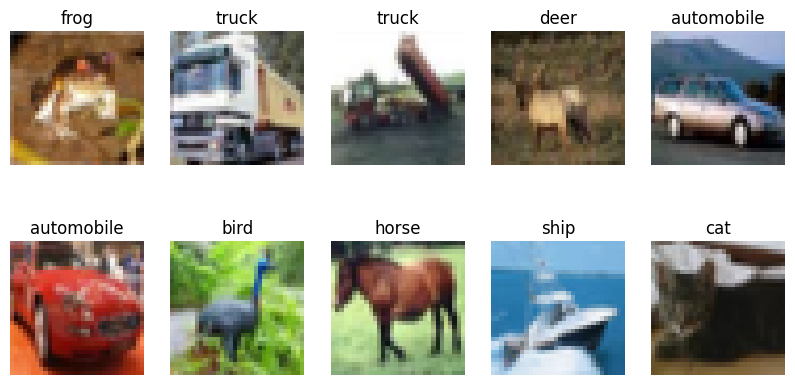

In [4]:
classes=["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]

plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(xtrain[i])
    plt.title(classes[np.argmax(ytrain[i])])
    plt.axis("off")
plt.show()

In [5]:
xtrain2=tf.image.resize(xtrain,(96,96))
xtest2=tf.image.resize(xtest,(96,96))

base=MobileNetV2(weights="imagenet",include_top=False,input_shape=(96,96,3))

base.trainable=False

x=base.output
x=GlobalAveragePooling2D()(x)
x=Dense(128,activation="relu")(x)
out=Dense(10,activation="softmax")(x)

model=Model(base.input,out)

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),loss="categorical_crossentropy",metrics=["accuracy"])

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 96, 96, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 48, 48,    │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 48, 48,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 48, 48,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 48, 48,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 48, 48,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 48, 48,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 49, 49,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 24, 24,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 24, 24,    │      2,304 │ block_1_depthwis

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [6]:
start=time.time()

history=model.fit(xtrain2,ytrain,batch_size=32,epochs=10,validation_split=0.1)

train_time=time.time()-start

print(train_time)

Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 318s 223ms/step - accuracy: 0.7497 - loss: 0.7191 - val_accuracy: 0.7784 - val_loss: 0.6223
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 304s 210ms/step - accuracy: 0.8042 - loss: 0.5539 - val_accuracy: 0.8026 - val_loss: 0.5721
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 332s 217ms/step - accuracy: 0.8250 - loss: 0.4918 - val_accuracy: 0.7980 - val_loss: 0.5758
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 315s 224ms/step - accuracy: 0.8415 - loss: 0.4470 - val_accuracy: 0.8084 - val_loss: 0.5486
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 306s 212ms/step - accuracy: 0.8579 - loss: 0.4006 - val_accuracy: 0.7902 - val_loss: 0.6310
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 310s 220ms/step - accuracy: 0.8712 - loss: 0.3609 - val_accuracy: 0.8148 - val_loss: 0.5696
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 309s 220ms/step - accuracy: 0.8852 - loss: 0.3229 - val_accuracy: 0.8008 - val_loss: 0.6201
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 321s 219ms/step - ac

In [7]:
loss,acc=model.evaluate(xtest2,ytest)

print(acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 61s 195ms/step - accuracy: 0.8001 - loss: 0.7163
0.8001000285148621


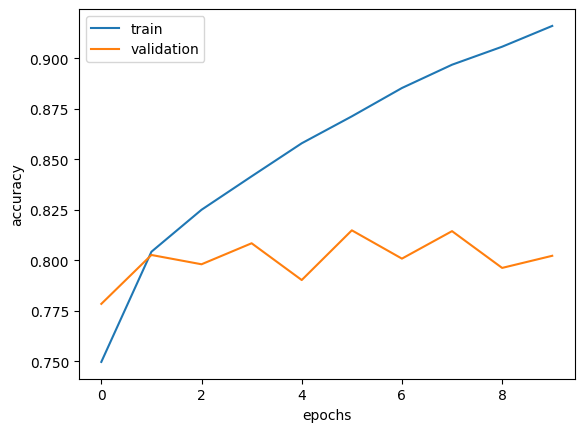

In [8]:
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.legend(["train","validation"])
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.show()

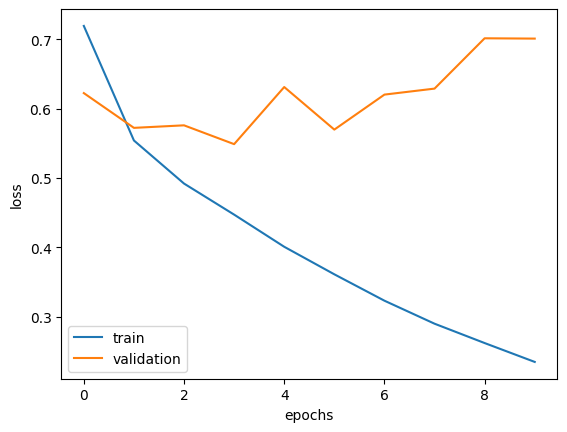

In [9]:
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.legend(["train","validation"])
plt.xlabel("epochs")
plt.ylabel("loss")
plt.show()

In [16]:
base.trainable=True

for layer in base.layers[:-20]:
    layer.trainable=False

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),loss="categorical_crossentropy",metrics=["accuracy"])

history2=model.fit(xtrain2,ytrain,batch_size=32,epochs=5,validation_split=0.1)

Epoch 1/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 494s 341ms/step - accuracy: 0.7712 - loss: 0.8877 - val_accuracy: 0.7850 - val_loss: 0.6666
Epoch 2/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 479s 325ms/step - accuracy: 0.8645 - loss: 0.3862 - val_accuracy: 0.8138 - val_loss: 0.6220
Epoch 3/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 467s 332ms/step - accuracy: 0.8988 - loss: 0.2851 - val_accuracy: 0.8134 - val_loss: 0.6721
Epoch 4/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 501s 331ms/step - accuracy: 0.9213 - loss: 0.2219 - val_accuracy: 0.7990 - val_loss: 0.7579
Epoch 5/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 481s 342ms/step - accuracy: 0.9382 - loss: 0.1767 - val_accuracy: 0.8162 - val_loss: 0.6954


In [10]:
loss,acc=model.evaluate(xtest2,ytest)

print(acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 60s 193ms/step - accuracy: 0.8001 - loss: 0.7163
0.8001000285148621


In [11]:
yp=model.predict(xtest2)

yp=np.argmax(yp,axis=1)
yt=np.argmax(ytest,axis=1)

print(precision_score(yt,yp,average="weighted"))
print(recall_score(yt,yp,average="weighted"))
print(f1_score(yt,yp,average="weighted"))

313/313 ━━━━━━━━━━━━━━━━━━━━ 62s 195ms/step
0.8039381188683534
0.8001
0.8004400050859437


In [12]:
print(classification_report(yt,yp,target_names=classes))

              precision    recall  f1-score   support

    airplane       0.83      0.83      0.83      1000
  automobile       0.86      0.92      0.89      1000
        bird       0.73      0.77      0.75      1000
         cat       0.64      0.67      0.65      1000
        deer       0.73      0.81      0.76      1000
         dog       0.73      0.69      0.71      1000
        frog       0.91      0.73      0.81      1000
       horse       0.85      0.83      0.84      1000
        ship       0.85      0.90      0.88      1000
       truck       0.92      0.85      0.88      1000

    accuracy                           0.80     10000
   macro avg       0.80      0.80      0.80     10000
weighted avg       0.80      0.80      0.80     10000



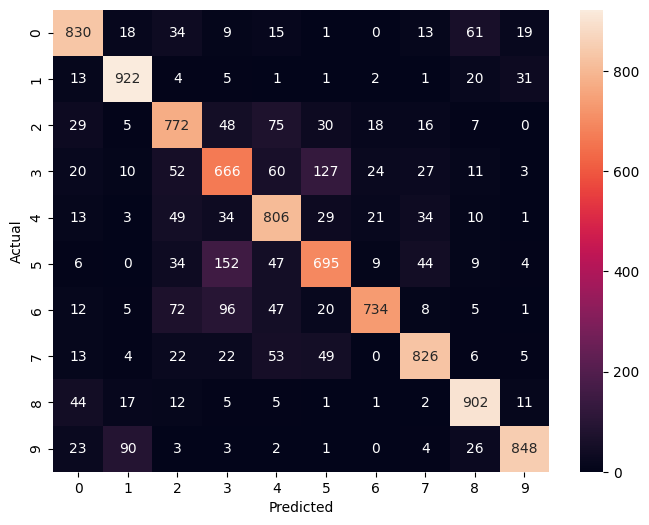

In [13]:
cm=confusion_matrix(yt,yp)

plt.figure(figsize=(8,6))
sns.heatmap(cm,annot=True,fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [14]:
params=model.count_params()

print(params)
print(train_time)

2423242
3137.230848312378


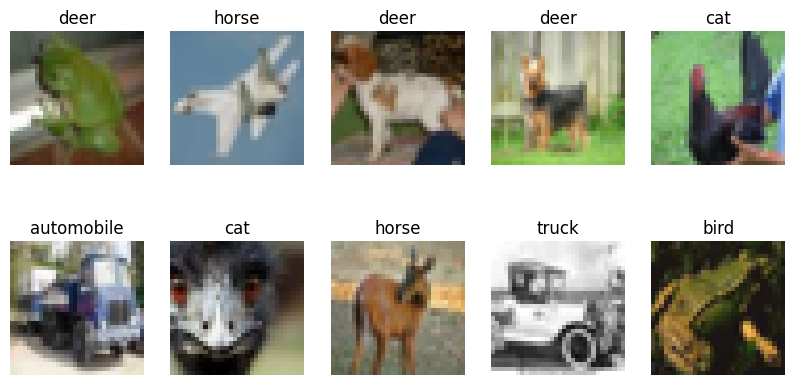

In [15]:
index=np.where(yt!=yp)[0][:10]

plt.figure(figsize=(10,5))

for i,j in enumerate(index):
    plt.subplot(2,5,i+1)
    plt.imshow(xtest[j])
    plt.title(classes[yp[j]])
    plt.axis("off")

plt.show()